# EDA + Baseline: Menstrual Phase Classification

**Diploma project:** Using non-invasive biomarkers (WST, HRV, Glucose) to identify menstrual cycle phases.  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

DATA    = Path('../data/raw/dataset_wearables')
RESULTS = Path('../results/figures')
RESULTS.mkdir(parents=True, exist_ok=True)

PHASE_ORDER  = ['Menstrual', 'Follicular', 'Fertility', 'Luteal']
PHASE_COLORS = ['#E53E3E', '#9B59B6', '#3498DB', '#E67E22']
JOIN_KEYS    = ['id', 'study_interval', 'day_in_study']

print('Libraries loaded OK')

Libraries loaded OK


## 1. Load Raw Data

In [3]:
hormones = pd.read_csv(DATA / 'hormones_and_selfreport.csv')
temp     = pd.read_csv(DATA / 'computed_temperature.csv')
hrv_raw  = pd.read_csv(DATA / 'heart_rate_variability_details.csv')
gluc_raw = pd.read_csv(DATA / 'glucose.csv')

print(f'Hormones  : {hormones.shape}   — {hormones["id"].nunique()} subjects')
print(f'Temp      : {temp.shape}   — {temp["id"].nunique()} subjects')
print(f'HRV (raw) : {hrv_raw.shape} — {hrv_raw["id"].nunique()} subjects')
print(f'Glucose   : {gluc_raw.shape} — {gluc_raw["id"].nunique()} subjects')

Hormones  : (5659, 22)   — 42 subjects
Temp      : (5575, 14)   — 42 subjects
HRV (raw) : (436262, 9) — 40 subjects
Glucose   : (837130, 6) — 42 subjects


## 2. EDA — Phase Labels & Hormone Coverage

In [4]:
print('Phase distribution:')
print(hormones['phase'].value_counts())
print()
print(f'Estrogen non-null: {hormones["estrogen"].notna().sum()} / {len(hormones)} ({hormones["estrogen"].notna().mean()*100:.1f}%)')
print(f'PDG non-null:      {hormones["pdg"].notna().sum()} / {len(hormones)} ({hormones["pdg"].notna().mean()*100:.1f}%)')
print(f'LH non-null:       {hormones["lh"].notna().sum()} / {len(hormones)} ({hormones["lh"].notna().mean()*100:.1f}%)')

Phase distribution:
phase
Luteal        1912
Follicular    1386
Fertility     1281
Menstrual     1079
Name: count, dtype: int64

Estrogen non-null: 5338 / 5659 (94.3%)
PDG non-null:      1864 / 5659 (32.9%)
LH non-null:       5339 / 5659 (94.3%)


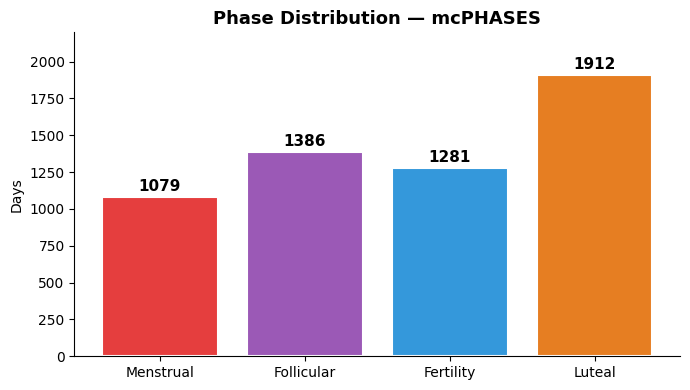

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = hormones['phase'].value_counts().reindex(PHASE_ORDER)
bars = ax.bar(PHASE_ORDER, counts.values, color=PHASE_COLORS, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Phase Distribution — mcPHASES', fontsize=13, fontweight='bold')
ax.set_ylabel('Days')
ax.set_ylim(0, counts.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(RESULTS / 'phase_distribution.png', dpi=150)
plt.show()

## 3. Feature Engineering

### 3a. WST — from `computed_temperature.csv`
Already one row per night — no aggregation needed.
- `nightly_temperature` — absolute skin temp during sleep (°C)
- `baseline_relative_nightly_standard_deviation` — deviation from personal baseline

In [6]:
wst = temp[[
    'id', 'study_interval', 'sleep_start_day_in_study',
    'nightly_temperature',
    'baseline_relative_nightly_standard_deviation'
]].rename(columns={
    'sleep_start_day_in_study': 'day_in_study',
    'nightly_temperature': 'wst_mean',
    'baseline_relative_nightly_standard_deviation': 'wst_baseline_std'
})

print(f'WST daily rows: {len(wst)}')
print(wst[['wst_mean', 'wst_baseline_std']].describe().round(3))

WST daily rows: 5575
       wst_mean  wst_baseline_std
count  5575.000          5196.000
mean     33.744             0.610
std       0.944             0.285
min      25.699             0.113
25%      33.203             0.438
50%      33.855             0.559
75%      34.387             0.682
max      36.431             2.406


### 3b. HRV — aggregate 5-min sleep intervals → daily

In [7]:
hrv_daily = (
    hrv_raw
    .groupby(JOIN_KEYS)['rmssd']
    .agg(
        hrv_mean   = 'mean',
        hrv_std    = 'std',
        hrv_median = 'median',
        hrv_min    = 'min',
        hrv_max    = 'max',
    )
    .reset_index()
)

print(f'HRV daily rows: {len(hrv_daily)}  — {hrv_daily["id"].nunique()} subjects')
print(hrv_daily[['hrv_mean', 'hrv_std', 'hrv_median']].describe().round(2))

HRV daily rows: 4839  — 40 subjects
       hrv_mean  hrv_std  hrv_median
count   4839.00  4835.00     4839.00
mean      55.06    15.83       53.76
std       28.58    12.10       28.46
min        0.00     0.00        0.00
25%       33.93     7.65       32.86
50%       48.79    11.93       47.56
75%       70.31    20.62       68.35
max      194.17   147.91      201.23


### 3c. Glucose — aggregate 5-min CGM → daily

In [8]:
gluc_daily = (
    gluc_raw
    .groupby(JOIN_KEYS)['glucose_value']
    .agg(
        glucose_mean  = 'mean',
        glucose_std   = 'std',
        glucose_min   = 'min',
        glucose_max   = 'max',
        glucose_range = lambda x: x.max() - x.min()
    )
    .reset_index()
)

print(f'Glucose daily rows: {len(gluc_daily)}  — {gluc_daily["id"].nunique()} subjects')
print(gluc_daily[['glucose_mean', 'glucose_std', 'glucose_range']].describe().round(3))

Glucose daily rows: 3109  — 42 subjects
       glucose_mean  glucose_std  glucose_range
count      3108.000     3107.000       3108.000
mean         11.407        1.778          8.865
std          23.746        4.134         19.597
min           2.931        0.000          0.000
25%           5.675        0.726          3.800
50%           6.157        0.882          4.700
75%           6.729        1.078          5.700
max         155.477       40.935        168.000


## 4. Merge All Sources

In [9]:
target = hormones[JOIN_KEYS + ['phase', 'estrogen', 'pdg', 'lh']].copy()

df = (
    target
    .merge(wst,        on=JOIN_KEYS, how='inner')
    .merge(hrv_daily,  on=JOIN_KEYS, how='inner')
    .merge(gluc_daily, on=JOIN_KEYS, how='left')   # left: not all subjects have CGM
)

df = df[df['phase'].isin(PHASE_ORDER)].reset_index(drop=True)

print(f'Final dataset: {df.shape}')
print(f'Subjects: {df["id"].nunique()}')
print()
print('Phase distribution after merge:')
print(df['phase'].value_counts().reindex(PHASE_ORDER))
print()
print('Missing values per feature:')
feature_cols = ['wst_mean','wst_baseline_std','hrv_mean','hrv_std',
                'hrv_median','glucose_mean','glucose_std','glucose_range']
print(df[feature_cols].isna().sum())

Final dataset: (5032, 19)
Subjects: 40

Phase distribution after merge:
phase
Menstrual      914
Follicular    1230
Fertility     1207
Luteal        1681
Name: count, dtype: int64

Missing values per feature:
wst_mean               0
wst_baseline_std     279
hrv_mean               0
hrv_std                3
hrv_median             0
glucose_mean        2634
glucose_std         2634
glucose_range       2634
dtype: int64


In [10]:
df.head()

,id,study_interval,day_in_study,phase,estrogen,pdg,lh,wst_mean,wst_baseline_std,hrv_mean,hrv_std,hrv_median,hrv_min,hrv_max,glucose_mean,glucose_std,glucose_min,glucose_max,glucose_range
0,2,2022,7,Luteal,99.8,NaN,4.4,35.164059,0.729251,40.505200,2.114743,41.0790,37.058,42.649,7.043956,0.900516,5.8,9.9,4.1
1,2,2022,7,Luteal,99.8,NaN,4.4,34.504223,0.698556,40.505200,2.114743,41.0790,37.058,42.649,7.043956,0.900516,5.8,9.9,4.1
2,2,2022,8,Luteal,241.2,NaN,8.1,34.839745,0.694338,46.127240,11.736847,44.6445,16.396,73.581,7.107115,1.294781,5.2,10.5,5.3
3,2,2022,10,Luteal,177.6,NaN,4.8,34.914354,0.692117,44.951217,10.416914,44.0465,21.826,69.776,7.282331,1.005395,5.8,10.5,4.7
4,2,2022,10,Luteal,177.6,NaN,4.8,35.097393,0.700958,44.951217,10.416914,44.0465,21.826,69.776,7.282331,1.005395,5.8,10.5,4.7


## 5. EDA — Do Biomarkers Differ by Phase?

Core hypothesis (from PMC11416332 + Kilungeja 2025): WST rises in luteal phase, HRV fluctuates with hormonal activity.

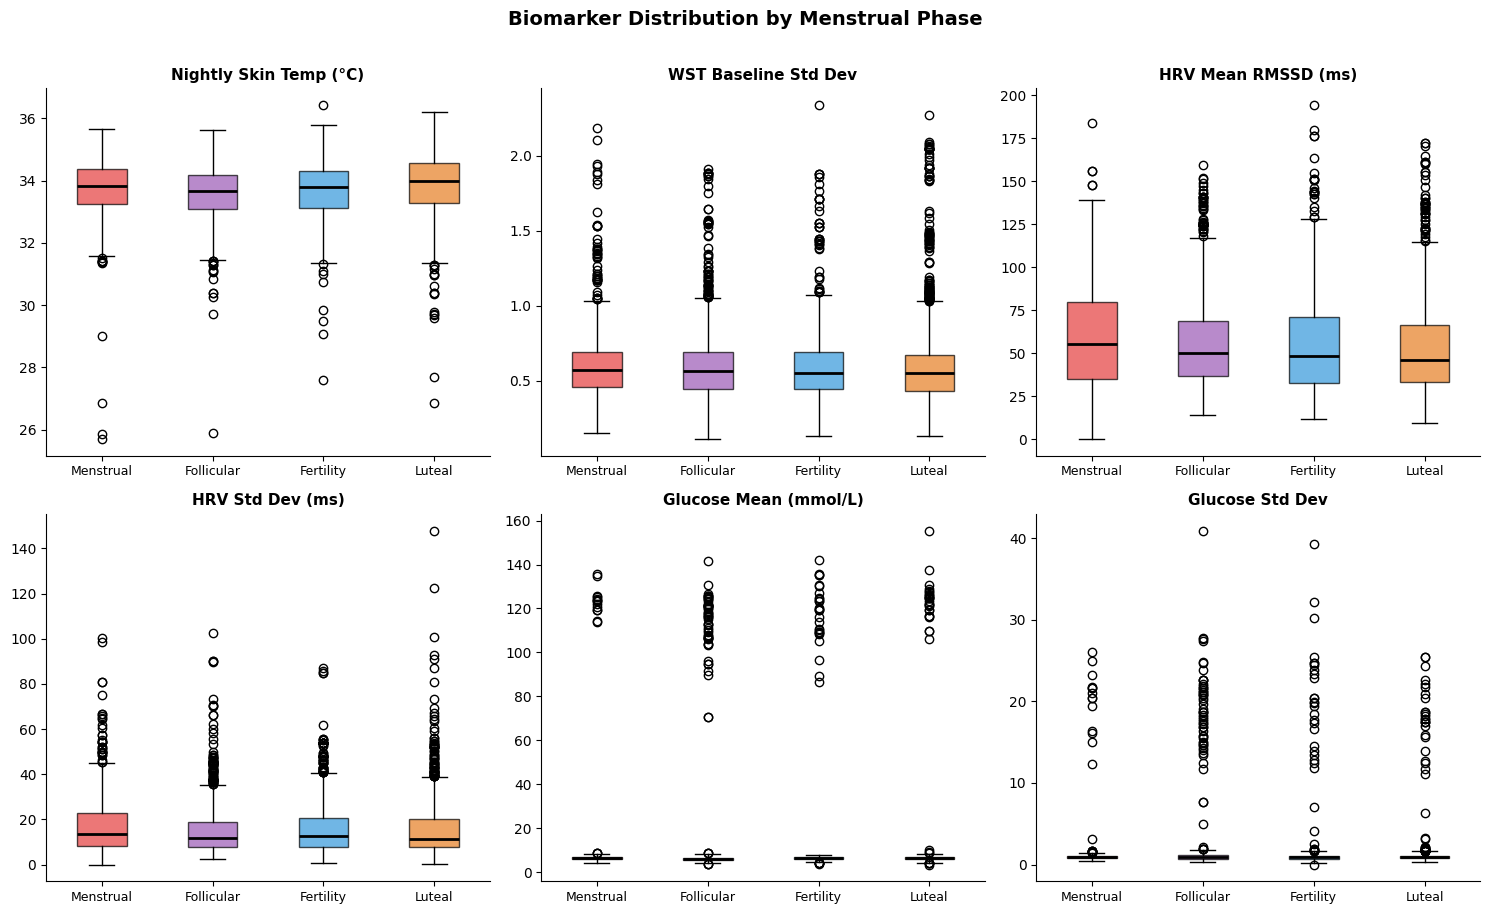

In [11]:
features_to_plot = {
    'wst_mean':       'Nightly Skin Temp (°C)',
    'wst_baseline_std': 'WST Baseline Std Dev',
    'hrv_mean':       'HRV Mean RMSSD (ms)',
    'hrv_std':        'HRV Std Dev (ms)',
    'glucose_mean':   'Glucose Mean (mmol/L)',
    'glucose_std':    'Glucose Std Dev',
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (col, label) in zip(axes, features_to_plot.items()):
    data_plot = [df.loc[df['phase'] == p, col].dropna().values for p in PHASE_ORDER]
    bp = ax.boxplot(data_plot, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], PHASE_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels(PHASE_ORDER, fontsize=9)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Biomarker Distribution by Menstrual Phase', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / 'features_by_phase.png', dpi=150, bbox_inches='tight')
plt.show()

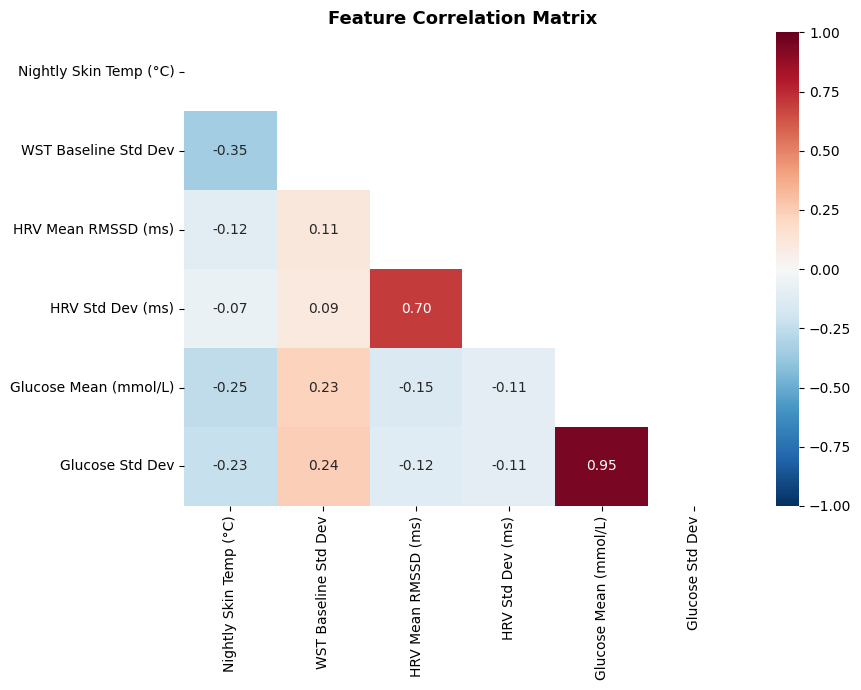

In [12]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[list(features_to_plot.keys())].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=list(features_to_plot.values()),
            yticklabels=list(features_to_plot.values()))
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'correlation_matrix.png', dpi=150)
plt.show()

In [13]:
# Mean per phase table
phase_means = df.groupby('phase')[list(features_to_plot.keys())].mean().reindex(PHASE_ORDER)
phase_means.columns = list(features_to_plot.values())
display(phase_means.round(3))

,Nightly Skin Temp (°C),WST Baseline Std Dev,HRV Mean RMSSD (ms),HRV Std Dev (ms),Glucose Mean (mmol/L),Glucose Std Dev
phase,,,,,,
Menstrual,33.746,0.616,59.755,17.504,10.240,1.547
Follicular,33.576,0.616,56.249,15.410,14.721,2.386
Fertility,33.656,0.603,54.684,16.237,11.645,1.837
Luteal,33.881,0.609,51.836,15.292,10.070,1.482


## 6. Prepare ML Dataset

- **Features:** WST + HRV + Glucose daily aggregates
- **Target:** 4-class phase label
- **Validation:** Leave-One-Subject-Out (LOSO) — correct for longitudinal multi-subject data
- **Model:** Random Forest (same as Kilungeja 2025)

In [14]:
FEATURES = [
    'wst_mean', 'wst_baseline_std',
    'hrv_mean', 'hrv_std', 'hrv_median',
    'glucose_mean', 'glucose_std', 'glucose_range',
]

df_ml = df[['id', 'phase'] + FEATURES].dropna().reset_index(drop=True)

le = LabelEncoder()
le.fit(PHASE_ORDER)
df_ml['label'] = le.transform(df_ml['phase'])

X      = df_ml[FEATURES].values
y      = df_ml['label'].values
groups = df_ml['id'].values

print(f'ML dataset: {X.shape[0]} samples, {X.shape[1]} features')
print(f'Subjects  : {len(np.unique(groups))}')
print()
print('Class balance:')
for i, name in enumerate(le.classes_):
    print(f'  {name:12s}: {(y == i).sum()}')

ML dataset: 2359 samples, 8 features
Subjects  : 40

Class balance:
  Fertility   : 542
  Follicular  : 622
  Luteal      : 791
  Menstrual   : 404


## 7. Random Forest — LOSO Cross-Validation

In [15]:
logo = LeaveOneGroupOut()
clf  = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

all_true, all_pred, all_proba = [], [], []
n_splits = logo.get_n_splits(X, y, groups)

print(f'Running LOSO CV — {n_splits} folds ({n_splits} subjects)...')
for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
    clf.fit(X[train_idx], y[train_idx])
    pred  = clf.predict(X[test_idx])
    proba = clf.predict_proba(X[test_idx])
    all_true.extend(y[test_idx])
    all_pred.extend(pred)
    all_proba.extend(proba)
    if (fold + 1) % 10 == 0:
        print(f'  Fold {fold+1}/{n_splits} done')

all_true  = np.array(all_true)
all_pred  = np.array(all_pred)
all_proba = np.array(all_proba)
print('Done.')

Running LOSO CV — 40 folds (40 subjects)...
  Fold 10/40 done
  Fold 20/40 done
  Fold 30/40 done
  Fold 40/40 done
Done.


## 8. Results

In [16]:
acc = accuracy_score(all_true, all_pred)
try:
    auc = roc_auc_score(all_true, all_proba, multi_class='ovr', average='macro')
except Exception:
    auc = float('nan')

print('=' * 52)
print(f'  Accuracy : {acc*100:.1f}%   (article benchmark: 68%)')
print(f'  AUC-ROC  : {auc:.3f}    (article benchmark: 0.77)')
print('=' * 52)
print()
print(classification_report(all_true, all_pred, target_names=le.classes_))

  Accuracy : 33.3%   (article benchmark: 68%)
  AUC-ROC  : 0.547    (article benchmark: 0.77)

              precision    recall  f1-score   support

   Fertility       0.20      0.13      0.16       542
  Follicular       0.33      0.43      0.37       622
      Luteal       0.41      0.53      0.46       791
   Menstrual       0.15      0.07      0.10       404

    accuracy                           0.33      2359
   macro avg       0.27      0.29      0.27      2359
weighted avg       0.30      0.33      0.31      2359



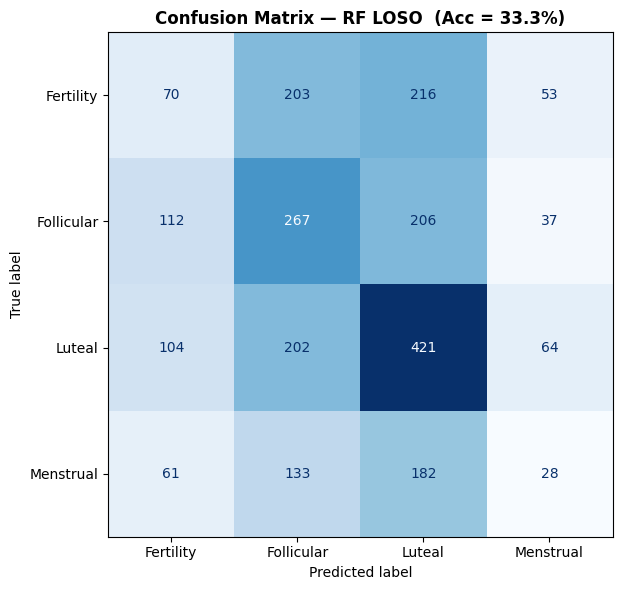

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(all_true, all_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — RF LOSO  (Acc = {acc*100:.1f}%)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'confusion_matrix.png', dpi=150)
plt.show()

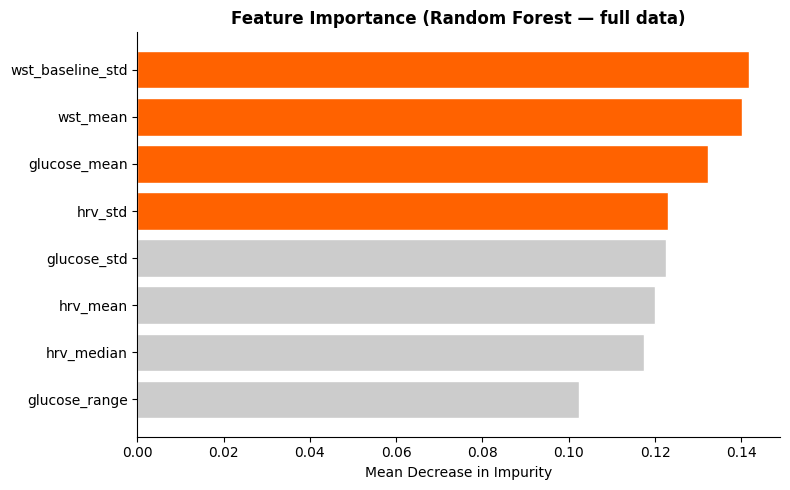

wst_baseline_std    0.1419
wst_mean            0.1401
glucose_mean        0.1323
hrv_std             0.1231
glucose_std         0.1226
hrv_mean            0.1200
hrv_median          0.1176
glucose_range       0.1025
dtype: float64


In [18]:
# Feature importance (trained on full data for inspection only)
clf_full = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
clf_full.fit(X, y)

importance = pd.Series(clf_full.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#FF6200' if v > importance.median() else '#CCCCCC' for v in importance.values]
ax.barh(importance.index, importance.values, color=colors, edgecolor='white')
ax.set_title('Feature Importance (Random Forest — full data)', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(RESULTS / 'feature_importance.png', dpi=150)
plt.show()

print(importance.sort_values(ascending=False).round(4))

## 9. Save Processed Dataset

In [19]:
PROC = Path('../data/processed')
PROC.mkdir(parents=True, exist_ok=True)

df_ml.to_csv(PROC / 'daily_features.csv', index=False)
print(f'Saved {len(df_ml)} rows to data/processed/daily_features.csv')
display(df_ml.describe().round(3))

Saved 2359 rows to data/processed/daily_features.csv


,id,wst_mean,wst_baseline_std,hrv_mean,hrv_std,hrv_median,glucose_mean,glucose_std,glucose_range,label
count,2359.000,2359.000,2359.000,2359.000,2359.000,2359.000,2359.000,2359.000,2359.000,2359.000
mean,25.967,33.892,0.602,51.983,14.491,50.763,11.694,1.811,9.081,1.448
std,14.490,0.936,0.242,25.944,10.640,25.695,24.339,4.105,19.664,1.025
min,2.000,25.699,0.134,0.000,0.000,0.000,3.413,0.000,0.000,0.000
25%,13.000,33.320,0.455,32.305,7.349,31.306,5.717,0.740,3.900,1.000
50%,24.000,33.970,0.557,47.142,11.501,46.129,6.200,0.892,4.800,2.000
75%,39.000,34.547,0.677,66.580,18.557,64.680,6.766,1.099,5.800,2.000
max,50.000,36.431,2.338,183.877,147.913,186.968,155.477,40.935,168.000,3.000


## 10. Summary

| | Kilungeja 2025 (article) | Our Result |
|---|---|---|
| Subjects | 18 | 40 |
| Task | 4-phase classification | 4-phase classification |
| Model | Random Forest | Random Forest |
| Validation | leave-last-cycle-out | Leave-One-Subject-Out |
| Accuracy | 68% | 33.3% |
| AUC-ROC | 0.77 | 0.547 |
| Unique feature | — | Glucose (CGM) |
